# 00 · Datos y features

Descarga el panel de mercado, construye los canales causales de `X`, calcula las
variables objetivo y termina con el EDA que fija las hipótesis del taller.

**Entradas:** `data/catalog.yaml`

**Salidas:** `data/raw/precios.parquet` · `data/processed/canales.parquet` ·
`data/processed/objetivos.parquet` · las figuras que enumera la última celda.

**Tiempo:** la primera vez lo domina la descarga de yfinance; con la caché puesta,
el bootstrap de las bandas.

In [1]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import norm

from src import calidad, datos, features, ventanas

# El catálogo se cachea por sesión: sin esto, editar el YAML con el kernel vivo
# regeneraría los canales con la versión antigua y en silencio.
config.cargar_catalogo.cache_clear()

## 1 · Qué descargamos

El universo entero sale de `data/catalog.yaml` —el índice, sus ETF sectoriales, el
VIX, la renta fija y el dólar—; aquí no hay ni un ticker escrito a mano. Quien manda
en la fecha de inicio son TLT, IEF y LQD, que no existen antes de julio de 2002, y
por eso el periodo arranca en 2003.

**La huella** es lo primero que hay que mirar: yfinance reescribe su histórico, así
que dos descargas en fechas distintas no dan lo mismo. Esa firma del contenido dice
si dos personas están trabajando sobre los mismos números.

In [3]:
precios = datos.descargar_precios()

print("Panel:", precios.shape, "·", precios.index[0].date(), "a", precios.index[-1].date())
print("Huella del contenido:", datos.huella(precios))
print(datos.cobertura(precios).head(3).to_string())

Panel: (5942, 15) · 2003-01-02 a 2026-08-14
Huella del contenido: 95170c3447ad
           ticker         rol desde_fuente inicio_panel  limita_arranque
nombre                                                                  
tesoro_20y    TLT  renta_fija   2002-07-30   2003-01-02             True
tesoro_10y    IEF  renta_fija   2002-07-30   2003-01-02             True
credito_ig    LQD  renta_fija   2002-07-30   2003-01-02             True


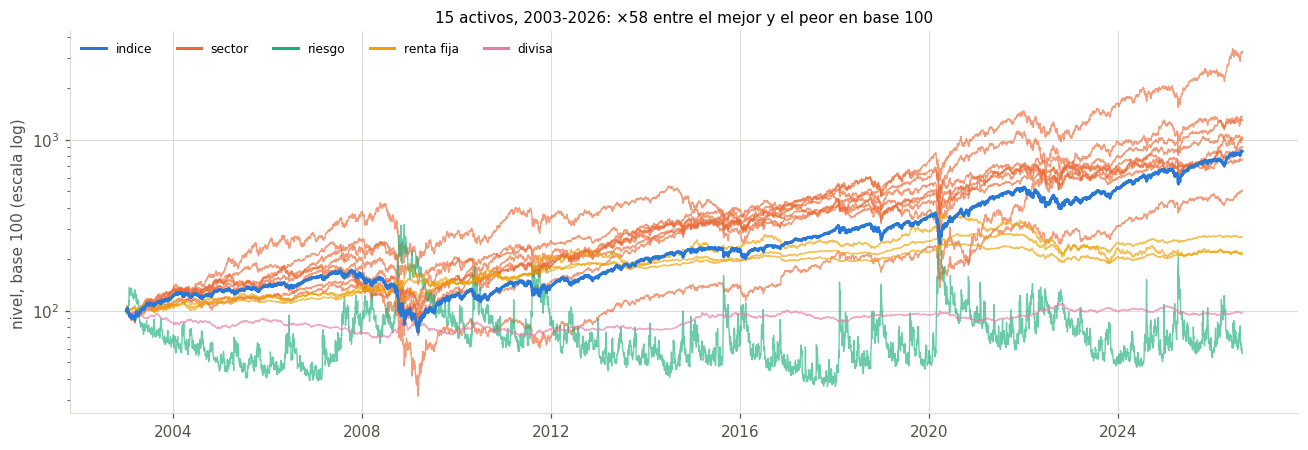

In [4]:
_final = (precios / precios.iloc[0]).iloc[-1]
_titulo = (f"{precios.shape[1]} activos, {precios.index[0].year}-{precios.index[-1].year}: "
           f"×{_final.max() / _final.min():.0f} entre el mejor y el peor en base 100")

fig, eje = plt.subplots(figsize=(12, 4.2))
viz.panel_mercado(precios, titulo=_titulo, eje=eje)
viz.guardar(fig, "panel_mercado")

### 1.1 · La auditoría de integridad

Sus filas se parten en dos **naturalezas**, no en dos grados de gravedad: los
*invariantes* son cosas imposibles en datos correctos y lanzan excepción; los
*avisos* marcan lo inverosímil pero posible y no lanzan nunca. Cuántas filas hay de
cada clase lo imprime la celda, desde `calidad.auditar_panel` y
`calidad.INVARIANTES`: no está escrito aquí a mano.

**Dos escalas para el mismo susto.** La celda imprime la mayor variación diaria del
panel *en porcentaje* y, por separado, el mayor *z robusto por columna*, que es lo
que mide de verdad el control `saltos`. **No apuntan al mismo día, y no es una
contradicción**: la mediana y la MAD se autoescalan a cada activo, de modo que un
salto enorme del VIX —que se mueve así de continuo— pesa menos que uno mucho más
pequeño en un ETF de crédito. Ésa es exactamente la doctrina de D23: se audita,
no se limpia.

**No se limpia nada**, y es una decisión: D23 (`docs/DECISIONES.md`) audita pero no
limpia, porque las técnicas habituales destruyen justo lo que este trabajo mide.
Winsorizar al 1 % dejaría la curtosis del mercado por debajo de la que produce
nuestro propio generador gaussiano; winsorizar al 5 % dejaría `curtosis_residuos`
por debajo de la banda de H1, con lo que la hipótesis del taller se volvería falsa
sobre los datos reales y **cualquier generador quedaría automáticamente no
refutado**. Las dos son **mediciones externas de D23**, hechas en un banco de
pruebas que no se conserva: ningún cuaderno de este repositorio las recalcula.

In [5]:
auditoria = calidad.auditar_panel(precios)

print(f"{len(auditoria)} controles: {len(calidad.INVARIANTES)} invariantes que lanzan y "
      f"{len(auditoria) - len(calidad.INVARIANTES)} avisos que no.")
auditoria

11 controles: 5 invariantes que lanzan y 6 avisos que no.


,veredicto,medida,limite,donde
control,,,,
tipos,ok,0.0,0.0,todo float64 + DatetimeIndex naive
indice,ok,0.0,0.0,dup=0 desorden=0 fin_semana=0
finitud,ok,0.0,0.0,sin NaN ni inf
positividad,ok,0.0,0.0,mínimo global 3.67
degeneradas,ok,0.0,0.0,corr máxima fuera de la diagonal 0.911
congelados,ok,3.0,3.0,"sector_materiales, racha de 3 sesiones"
saltos,ok,27.0,50.0,credito_ig 2008-09-29
calendario,ok,5.0,10.0,2006-12-29 a 2007-01-03
densidad,ok,250.0,240.0,mínimo en 2012 (250 sesiones)


In [6]:
# Las dos escalas del mismo susto: la mayor variación en porcentaje y el mayor z
# robusto por columna, que es lo que mide de verdad el control `saltos`.
_d = np.log(precios).diff() - np.log(precios).diff().median()
_zrob = _d.abs() / (1.4826 * _d.abs().median())
_pct = precios.pct_change()
_i, _j = np.unravel_index(np.nanargmax(np.abs(_pct.to_numpy())), _pct.shape)

print(f"Mayor variación diaria: {_pct.columns[_j]} {_pct.index[_i].date()} "
      f"{_pct.iloc[_i, _j] * 100:+.1f} %, con z robusto {_zrob.iloc[_i, _j]:.1f}")
print(f"Mayor z robusto, que es lo que mide el control `saltos`: "
      f"{auditoria.loc['saltos', 'donde']}, z = {auditoria.loc['saltos', 'medida']:.1f}")

Mayor variación diaria: vix 2018-02-05 +115.6 %, con z robusto 14.3
Mayor z robusto, que es lo que mide el control `saltos`: credito_ig 2008-09-29, z = 27.0


## 2 · De precios a `X`: los canales causales

Los precios en crudo no sirven como entrada: mezclan niveles y escalas. Se derivan
los canales que declara el catálogo —once de retorno, que son el índice, los nueve
sectores y el dólar, más nueve derivadas de estrés— y son lo que verá el modelo.

**Todos son causales**: el valor en `t` sólo usa información de `t` o anterior. El
error clásico es el z-score sobre la muestra completa, que mejora las métricas
porque el modelo acaba conociendo la media del futuro.

El contraste lo comprueba canal a canal y busca **dos** formas distintas de mirar
al futuro:

| columna | caza transformaciones que… | ejemplo |
|---|---|---|
| `discrepancia` | **reescriben** el pasado | z-score global |
| `huerfanas` | lo **desplazan** | `shift(-1)`, media centrada |

Las dos tienen que dar cero en todos los canales, y el máximo de cada una lo
imprime la celda siguiente: es la tabla que este párrafo describe y que hasta ahora
no se veía. Además la función reconstruye los canales por su cuenta y comprueba que
coincide con `construir_canales`: dos implementaciones que se vigilan la una a la
otra.

In [7]:
canales = features.construir_canales(precios)
causalidad = features.contraste_causalidad(precios)

print("X:", canales.shape, "·", canales.index[0].date(), "a", canales.index[-1].date())
print("Contraste causal superado:", int(causalidad["causal"].sum()), "de", len(causalidad))
print("Sesiones que consume el arranque de los z-score:", len(precios) - len(canales))
print(causalidad[["discrepancia", "huerfanas"]].max().to_string())

X: (5670, 20) · 2004-02-02 a 2026-08-14
Contraste causal superado: 20 de 20
Sesiones que consume el arranque de los z-score: 272
discrepancia    0.0
huerfanas       0.0


### 2.1 · Cuántos canales se encienden a la vez

El panel está apagado en casi dos de cada tres sesiones, y cuando se enciende lo
hace **en bloque**. Ésa es la señal de régimen, y es la razón de modelar los
canales conjuntamente en vez de uno a uno.

- La tipificación se ajusta **sólo con el tramo de entrenamiento** y se aplica
  después a toda la serie. En un cuaderno cuyo argumento central es que todo es
  causal, tipificar con la muestra completa sería una vulnerabilidad gratuita.
- El umbral `|z| > 2` es una convención de lectura, no un parámetro del modelo:
  nada aguas abajo depende de él.

In [8]:
_train = canales.index <= pd.Timestamp(config.particiones().train_hasta)
_z = (canales - canales[_train].mean()) / canales[_train].std()
activacion = (_z.abs() > 2).sum(axis=1) / canales.shape[1]
apagadas = float((activacion == 0).mean())
multitud = int((activacion >= 0.5).sum())

print(f"Sesiones sin ningún canal en |z| > 2: {apagadas * 100:.1f} %")
print(f"Sesiones con la mitad o más encendidos: {multitud}")
print(f"Máximo simultáneo: {int(activacion.max() * canales.shape[1])} canales, "
      f"el {activacion.idxmax().date()}")

Sesiones sin ningún canal en |z| > 2: 63.4 %
Sesiones con la mitad o más encendidos: 130
Máximo simultáneo: 18 canales, el 2008-10-13


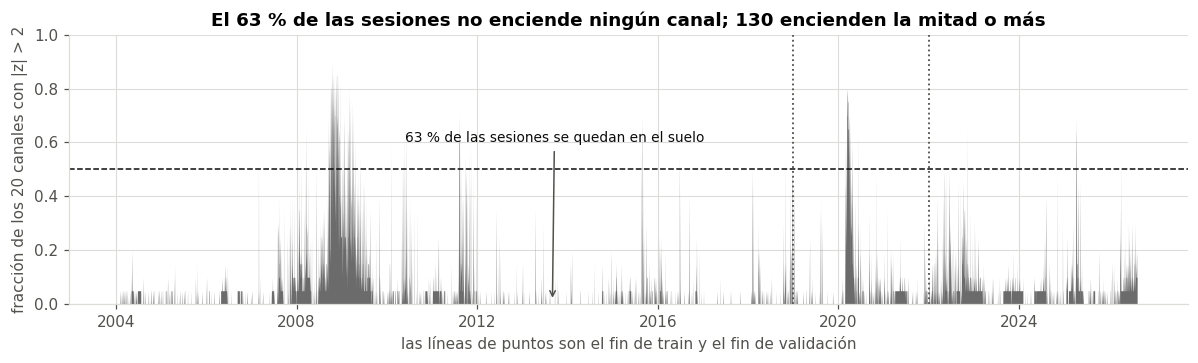

In [9]:
fig, eje = plt.subplots(figsize=(11, 3.4))
eje.fill_between(activacion.index, activacion, color=viz.GRIS_CONTEXTO, lw=0)
for _f in (config.particiones().train_hasta, config.particiones().val_hasta):
    eje.axvline(pd.Timestamp(_f), color=viz.TINTA_SECUNDARIA, linestyle=":", lw=1.2)
eje.axhline(0.5, color=viz.TINTA_PRIMARIA, linestyle="--", lw=1.0)
# El porcentaje del título no tenía ningún elemento gráfico que lo anclara: la
# anotación señala un tramo largo pegado al suelo para que se pueda comprobar.
eje.annotate(f"{apagadas * 100:.0f} % de las sesiones se quedan en el suelo",
             xy=(pd.Timestamp("2013-09-01"), 0.012), xytext=(0.30, 0.60),
             textcoords="axes fraction", fontsize=9, color=viz.TINTA_PRIMARIA,
             arrowprops=dict(arrowstyle="->", lw=1.0, color=viz.TINTA_SECUNDARIA))
eje.set_ylim(0, 1)
eje.set_ylabel(f"fracción de los {canales.shape[1]} canales con |z| > 2")
eje.set_xlabel("las líneas de puntos son el fin de train y el fin de validación")
eje.set_title(f"El {apagadas * 100:.0f} % de las sesiones no enciende ningún canal; "
              f"{multitud} encienden la mitad o más", fontsize=12)
viz.guardar(fig, "00_activacion_canales")

### 2.2 · La matriz entera

Lo que hay que buscar son las **columnas verticales**: momentos en que casi todos
los canales se encienden a la vez.

- La figura anterior tipifica sólo con train y de ahí sale su porcentaje. El color
  de este mapa, en cambio, se tipifica con la muestra completa y **sólo para
  pintar**: iguala escalas que difieren en dos órdenes de magnitud para que un
  canal no monopolice el color. No se guarda y no alimenta a ningún modelo.
- Una franja plana en un canal de **retorno** sí sería un canal constante. En los
  canales `z`, en cambio, una franja larga es **persistencia de régimen** y no un
  fallo: el spread de crédito tras 2008, el drawdown durante la recuperación, la
  pendiente de la curva o la correlación acción-bono se quedan quietos años enteros
  porque el mercado se queda quieto. Una columna en blanco, ésa sí, sería un hueco
  en el índice.

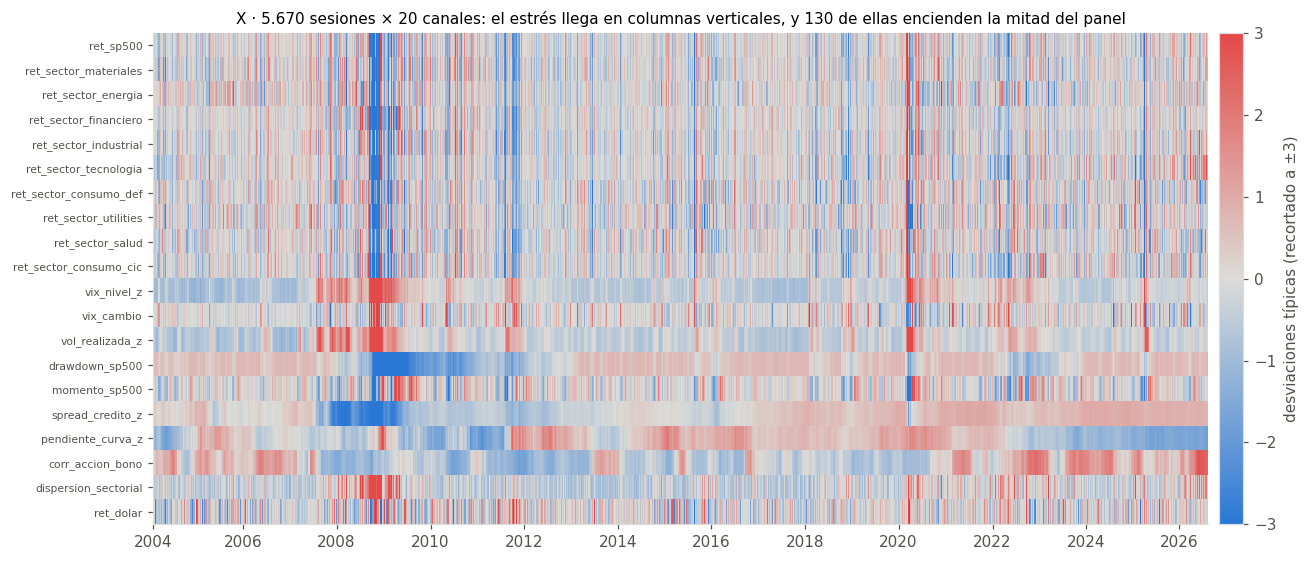

In [10]:
fig, eje = plt.subplots(figsize=(12, 5.2))
viz.mapa_canales(canales, eje=eje, titulo=(
    f"X · {len(canales):,}".replace(",", ".")
    + f" sesiones × {canales.shape[1]} canales: el estrés llega en columnas "
      f"verticales, y {multitud} de ellas encienden la mitad del panel"))
viz.guardar(fig, "mapa_canales")

## 3 · Las variables objetivo

Miran al futuro a propósito: son la etiqueta, no una entrada. Para la ventana que
termina en `t` se calculan sobre los 21 días **siguientes**, sin incluir `t`.

- `vol_futura` — volatilidad realizada anualizada. Es la tarea de regresión.
- `ret_futuro` y `dd_futuro` — retorno acumulado y caída máxima, de apoyo.

El régimen, que es la tarea principal, no se calcula aquí: sale del HMM del cuaderno
01, que se ajusta sólo con el tramo de entrenamiento.

Se guarda `objetivos` completo y `canales` recortado. El cuaderno 02 los alinea por
fecha, así que recortar aquí no cambiaría ni una ventana. El `count` del resumen no
llega al número de filas de `X`, y la celda dice por qué: a las últimas sesiones del
panel les falta el futuro sobre el que se define el objetivo.

In [11]:
objetivos = features.objetivos(precios, config.ventanas().horizonte)
src.DIR_PROCESADO.mkdir(parents=True, exist_ok=True)

canales.to_parquet(src.DIR_PROCESADO / "canales.parquet")
objetivos.to_parquet(src.DIR_PROCESADO / "objetivos.parquet")

print("canales.parquet  ", canales.shape, "· huella", datos.huella(canales))
print("objetivos.parquet", objetivos.shape, "·", ", ".join(objetivos.columns))

canales.parquet   (5670, 20) · huella f43482436dcd
objetivos.parquet (5942, 3) · vol_futura, ret_futuro, dd_futuro


In [12]:
resumen_objetivos = objetivos.loc[canales.index].describe().T.round(3)
_sin_futuro = len(canales) - int(resumen_objetivos["count"].min())

print(f"El count se queda en {int(resumen_objetivos['count'].min())} y no en {len(canales)}: "
      f"a las {_sin_futuro} últimas sesiones del panel les faltan los "
      f"{config.ventanas().horizonte} días de futuro que definen el objetivo.")
resumen_objetivos

El count se queda en 5649 y no en 5670: a las 21 últimas sesiones del panel les faltan los 21 días de futuro que definen el objetivo.


,count,mean,std,min,25%,50%,75%,max
vol_futura,5649.0,0.156,0.108,0.035,0.094,0.128,0.181,0.976
ret_futuro,5649.0,0.007,0.046,-0.400,-0.013,0.013,0.033,0.224
dd_futuro,5649.0,-0.041,0.042,-0.400,-0.050,-0.029,-0.016,-0.003


---

# 4 · Mini EDA

El dataset ya está escrito. Quedan tres preguntas, y sus respuestas se usan en los
cuadernos 05 a 14.

## 4.1 · ¿Cuántos datos independientes hay de verdad?

Muchos menos de los que parece. Dos ventanas consecutivas comparten 59 de sus 60
días, así que contar ventanas infla el tamaño muestral casi dos órdenes de magnitud.

- La celda imprime el recuento **del panel completo** y el **del tramo de train**,
  con la misma función y distinta muestra. Ninguno de los dos es el 45 que el README
  publica para train: **ése sale de otra convención**, la del cuaderno 02, que
  cuenta sobre ventanas ya construidas. Son tres números correctos de tres preguntas
  distintas, y no hay que reconciliarlos.
- Los episodios de estrés de este cuaderno son rachas de `vix_nivel_z > 2`
  fusionadas. **No** son las rachas de crisis por partición del cuaderno 02, que se
  cuentan sobre la etiqueta del HMM: tampoco esos dos recuentos son el mismo objeto.

En la figura cada celda es un bloque que **no comparte ni una sesión** con sus
vecinas: se pueden contar con la vista. Las teñidas, las que contienen estrés, son
un puñado, y sólo las de train alimentan a los generadores.

In [13]:
efectivo = ventanas.tamano_muestral_efectivo(canales.index, config.ventanas())
_en_train = canales.index <= pd.Timestamp(config.particiones().train_hasta)
efectivo_train = ventanas.tamano_muestral_efectivo(canales.index[_en_train], config.ventanas())

print("Panel completo\n" + efectivo.to_string())
print("\nTramo de train, con la misma función y otra muestra\n" + efectivo_train.to_string())

Panel completo
sesiones              5670.0
ventanas_nominales    5590.0
bloques_disjuntos       70.0
factor_inflacion        79.9

Tramo de train, con la misma función y otra muestra
sesiones              3755.0
ventanas_nominales    3675.0
bloques_disjuntos       46.0
factor_inflacion        79.9


In [14]:
episodios = features.episodios_estres(canales["vix_nivel_z"])
episodios_train = episodios[episodios["inicio"] <= config.particiones().train_hasta]
crisis_entrenables = int((episodios_train["sesiones_estres"] > config.ventanas().horizonte).sum())
parte_episodio = pd.cut(
    episodios["inicio"],
    [pd.Timestamp.min, pd.Timestamp(config.particiones().train_hasta),
     pd.Timestamp(config.particiones().val_hasta), pd.Timestamp.max],
    labels=["train", "validación", "test"])

print(f"Episodios de estrés del panel: {len(episodios)} · en train: {len(episodios_train)}")
print(f"De una sola sesión: {int((episodios['sesiones_estres'] == 1).sum())}")
print(f"En train por encima del horizonte de {config.ventanas().horizonte}: {crisis_entrenables}")

Episodios de estrés del panel: 11 · en train: 7
De una sola sesión: 5
En train por encima del horizonte de 21: 2


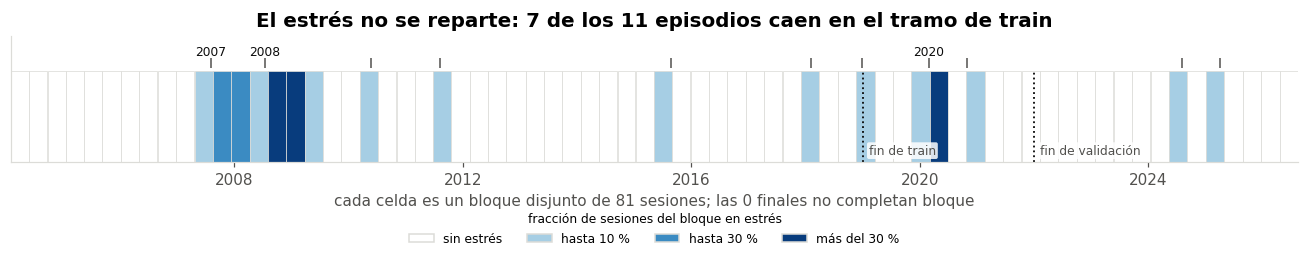

In [15]:
fig, eje = plt.subplots(figsize=(12, 2.8))
viz.carril_bloques(canales["vix_nivel_z"] > 2, episodios, config.ventanas(),
                   config.particiones(), eje=eje,
                   titulo=(f"El estrés no se reparte: {len(episodios_train)} de los "
                           f"{len(episodios)} episodios caen en el tramo de train"))
viz.guardar(fig, "muestra_efectiva")

### 4.1.1 · Los episodios, uno a uno

Casi todos los episodios de estrés son **más cortos que el horizonte que hay que
predecir**, y dibujarlos uno a uno es la única forma de verlo.

- La escala es **lineal a propósito**. En escala logarítmica una barra de una sesión
  mide cero y desaparece, que es justo el argumento de la figura.
- El recuento tiene **dos grados de libertad** y no se puede citar sin declarar los
  dos: el umbral sobre `vix_nivel_z` y la regla de fusión. La celda siguiente barre
  los dos y enseña lo que sale.
- Por la **regla de fusión** se adopta 63 sesiones, tres veces el horizonte: de las
  tres que se barren es la **más conservadora**, la que hace parecer más pequeña
  nuestra propia muestra.
- Por el **umbral** se adopta la convención de mercado, que **no** es la opción más
  conservadora, y conviene decirlo: el barrido de umbrales vecinos se imprime al
  lado para que se vea cuánto pesa este grado de libertad. Es el que más pesa de
  los dos, y ninguno de los dos se eligió a posteriori.

In [16]:
_senal = canales["vix_nivel_z"]
print("Episodios según el umbral de |z| del VIX:",
      {u: len(features.episodios_estres(_senal, umbral=u)) for u in (1.5, 2.0, 2.5)})
print("Episodios según la regla de fusión, con el umbral en 2,0:",
      {h: len(features.episodios_estres(_senal, hueco=h)) for h in (21, 42, 63)})

Episodios según el umbral de |z| del VIX: {1.5: 13, 2.0: 11, 2.5: 5}
Episodios según la regla de fusión, con el umbral en 2,0: {21: 17, 42: 13, 63: 11}


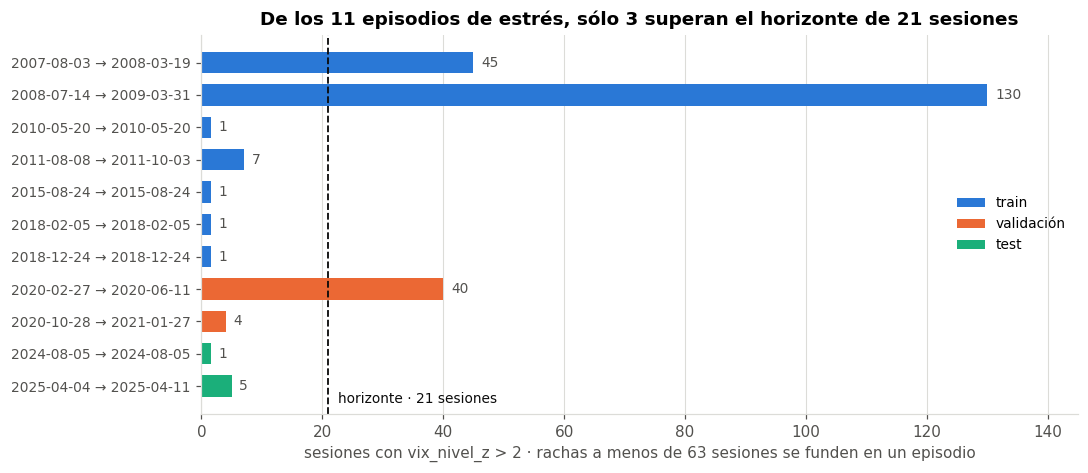

In [17]:
_v = config.ventanas()
_tonos = dict(zip(["train", "validación", "test"], viz.PALETA[:3]))
_y = np.arange(len(episodios))[::-1]
_n = episodios["sesiones_estres"].to_numpy()

fig, eje = plt.subplots(figsize=(10, 4.4))
# Anchura mínima dibujada: en escala lineal un episodio de una sesión no llega a
# un píxel y desaparecería, que es justo lo que la figura quiere enseñar.
eje.barh(_y, np.maximum(_n, 1.6), height=0.66, color=[_tonos[c] for c in parte_episodio])
for _pos, _s in zip(_y, _n):
    eje.annotate(f"{_s}", xy=(max(_s, 1.6), _pos), xytext=(5, 0), va="center",
                 textcoords="offset points", fontsize=9, color=viz.TINTA_SECUNDARIA)
eje.axvline(_v.horizonte, color=viz.TINTA_PRIMARIA, linestyle="--", lw=1.2)
eje.annotate(f"horizonte · {_v.horizonte} sesiones", xy=(_v.horizonte, 0.02),
             xycoords=eje.get_xaxis_transform(), xytext=(6, 0), va="bottom",
             textcoords="offset points", fontsize=9, color=viz.TINTA_PRIMARIA)
eje.set_yticks(_y, [f"{a.date()} → {b.date()}"
                    for a, b in zip(episodios["inicio"], episodios["fin"])], fontsize=9)
eje.set_xlim(0, 145)
eje.grid(False, axis="y")
eje.set_xlabel(f"sesiones con vix_nivel_z > 2 · rachas a menos de "
               f"{3 * _v.horizonte} sesiones se funden en un episodio")
eje.set_title(f"De los {len(episodios)} episodios de estrés, sólo "
              f"{int((_n > _v.horizonte).sum())} superan el horizonte de "
              f"{_v.horizonte} sesiones", fontsize=12)
eje.legend(handles=[Patch(facecolor=t, label=n) for n, t in _tonos.items()],
           loc="center right", fontsize=9)
viz.guardar(fig, "00_episodios_de_estres")

### 4.1.2 · La cascada: del dataset a un dígito

Es la respuesta a "¿por qué necesitáis datos sintéticos?". El dataset ofrece miles
de filas; el número de **eventos de crisis independientes** con los que se puede
entrenar un generador es de un solo dígito.

**Esta es la figura que va al slide.**

- Los cuatro escalones no son cuatro maneras de contar lo mismo: son poblaciones
  cada vez más pequeñas y más informativas. Con un matiz que hay que declarar: los
  tres primeros se miden sobre el panel entero y el último estrecha además la
  muestra al **tramo de entrenamiento**, así que no están estrictamente anidados.
- Por eso el último escalón y el título de `00_episodios_de_estres` no cuentan lo
  mismo: entre los episodios largos del panel entero está el de 2020, que cae en
  validación y no alimenta a ningún generador. Los dos recuentos son correctos y no
  hay que unificarlos.
- La escala es logarítmica porque entre el primer escalón y el último hay tres
  órdenes de magnitud. El punto marca la posición exacta y la cifra va escrita al
  lado, así que la comparación no depende de leer el eje.

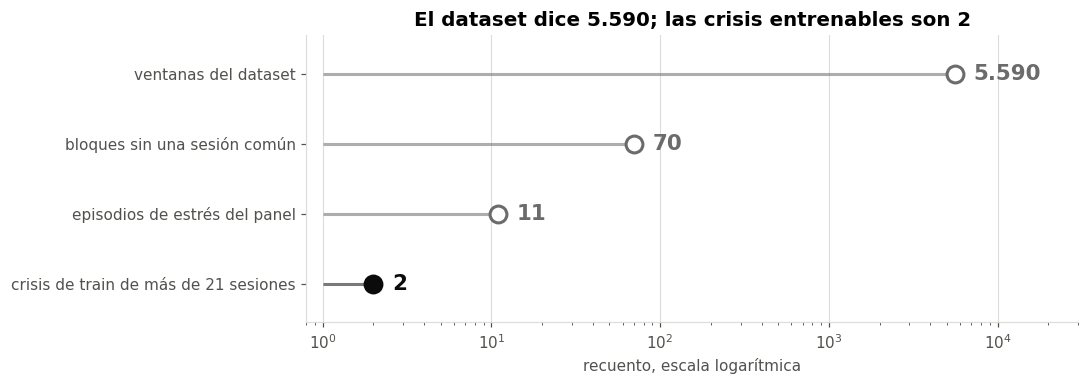

In [18]:
_escalones = [
    (int(efectivo["ventanas_nominales"]), "ventanas del dataset"),
    (int(efectivo["bloques_disjuntos"]), "bloques sin una sesión común"),
    (len(episodios), "episodios de estrés del panel"),
    (crisis_entrenables, f"crisis de train de más de {config.ventanas().horizonte} sesiones"),
]

fig, eje = plt.subplots(figsize=(10, 3.6))
_y = np.arange(len(_escalones))[::-1]
for _pos, (_valor, _), _ultimo in zip(_y, _escalones, [0, 0, 0, 1]):
    _tono = viz.TINTA_PRIMARIA if _ultimo else viz.GRIS_CONTEXTO
    eje.hlines(_pos, 1, _valor, color=_tono, lw=2.0, alpha=0.55)
    eje.plot(_valor, _pos, marker="o", markersize=11, color=_tono,
             markerfacecolor=_tono if _ultimo else "white", markeredgewidth=2.0)
    eje.annotate(f"{_valor:,}".replace(",", "."), xy=(_valor, _pos), xytext=(12, 0),
                 textcoords="offset points", va="center", fontsize=14,
                 fontweight="bold", color=_tono)
eje.set_xscale("log")
eje.set_xlim(0.8, 30000)
eje.set_yticks(_y, [e for _, e in _escalones], fontsize=10)
eje.set_ylim(-0.55, len(_escalones) - 0.45)
eje.grid(False, axis="y")
eje.set_xlabel("recuento, escala logarítmica")
eje.set_title(f"El dataset dice {_escalones[0][0]:,}".replace(",", ".")
              + f"; las crisis entrenables son {crisis_entrenables}", fontsize=13)
viz.guardar(fig, "00_escasez_estructural")

## 4.2 · ¿Podría generar esto una gaussiana?

Es la pregunta que justifica usar modelos generativos y no un muestreo estadístico.
Se responde midiendo los hechos estilizados de Cont (2001) sobre los datos reales y
comparándolos con cuatro procesos de respuesta conocida: `gaussiano` (una normal
única), `t4` (colas gruesas sin memoria), `garch11` (volatilidad variable) y
`mezcla` (una normal por régimen).

`mezcla` es la fila que importa: **es lo que produce nuestro generador gaussiano**,
porque D10 (un modelo independiente por régimen, `docs/DECISIONES.md`) no genera una
normal sino una mezcla de escala. Comparar contra la primera columna sería comparar
contra un objeto que este repositorio no implementa.

La banda de cada fila es un **bootstrap de bloques móviles** sobre el propio
mercado: mide el error muestral de *nuestra* estimación, no contrasta una hipótesis.
Una fila cuya banda contiene el valor de un proceso es una fila que no discrimina.

In [19]:
r = canales["ret_sp500"]
extremos = ["ret_sp500", "ret_sector_financiero", "ret_sector_consumo_cic", "ret_sector_energia"]
hechos = features.hechos_estilizados(canales[extremos])
banda = features.banda_bootstrap(r)

# `beta_acf_abs` se guarda ANTES del drop: su banda es lo que justifica retirarla.
beta = pd.concat([hechos.loc["beta_acf_abs"], banda.loc["beta_acf_abs"]])
tabla = (hechos.drop(index="beta_acf_abs")
         .rename(columns=lambda c: c.replace("ret_sector_", "").replace("ret_", ""))
         .join(banda).join(features.calibracion_hechos()))

print(f"Curtosis cruda de ret_sp500: {r.kurt() + 3:.3f}; sin el 16 de marzo de 2020, "
      f"{r.drop(pd.Timestamp('2020-03-16')).kurt() + 3:.3f}: la mueve una sola sesión.")
print(f"beta_acf_abs se retira: banda [{beta['banda_inf']:.2f} – {beta['banda_sup']:.2f}], "
      f"y el mercado deja {beta['ret_sp500']:.2f} dentro de ella.")
tabla.round(3)

Curtosis cruda de ret_sp500: 16.470; sin el 16 de marzo de 2020, 14.654: la mueve una sola sesión.
beta_acf_abs se retira: banda [0.35 – 1.20], y el mercado deja 0.46 dentro de ella.


,sp500,financiero,consumo_cic,energia,banda_inf,banda_sup,gaussiano,t4,garch11,mezcla
curtosis,16.470,20.566,11.213,16.081,7.264,21.478,2.983,11.112,7.483,8.026
curtosis_h21,6.790,10.412,5.328,9.827,3.910,24.171,2.704,3.187,5.533,7.156
curtosis_residuos,7.229,6.122,5.088,5.256,5.567,10.297,3.354,12.426,3.199,3.447
asimetria,-0.476,-0.209,-0.471,-0.713,-0.831,-0.159,0.006,0.104,-0.025,0.140
ac1_retorno,-0.117,-0.111,-0.047,-0.053,-0.188,-0.042,-0.007,0.010,0.014,0.010
ac1_absoluto,0.313,0.429,0.268,0.258,0.165,0.406,-0.009,0.002,0.243,0.310
ac10_absoluto,0.308,0.370,0.256,0.269,0.163,0.357,0.002,0.003,0.226,0.257
ac40_absoluto,0.160,0.320,0.182,0.141,0.053,0.195,0.014,0.005,0.167,0.097
ac100_absoluto,0.084,0.199,0.109,0.082,-0.018,0.112,-0.002,-0.005,0.082,-0.007
apalancamiento,-0.099,-0.068,-0.054,-0.111,-0.129,-0.063,0.001,-0.010,0.012,0.013


Las dos propiedades más difíciles de imitar, dibujadas sobre el mercado: las colas
y la memoria de la magnitud. Cada panel afirma su cifra en su propio subtítulo, así
que no hace falta transcribirla aquí.

- La supervivencia se dibuja en lugar de un histograma porque el histograma pinta la
  masa central, que es donde real y normal coinciden, y esconde la cola.
- En la ACF lo que se juzga es la **posición respecto a la banda i.i.d.**, no la
  forma del decaimiento: por eso los ejes son lineales y no log-log.

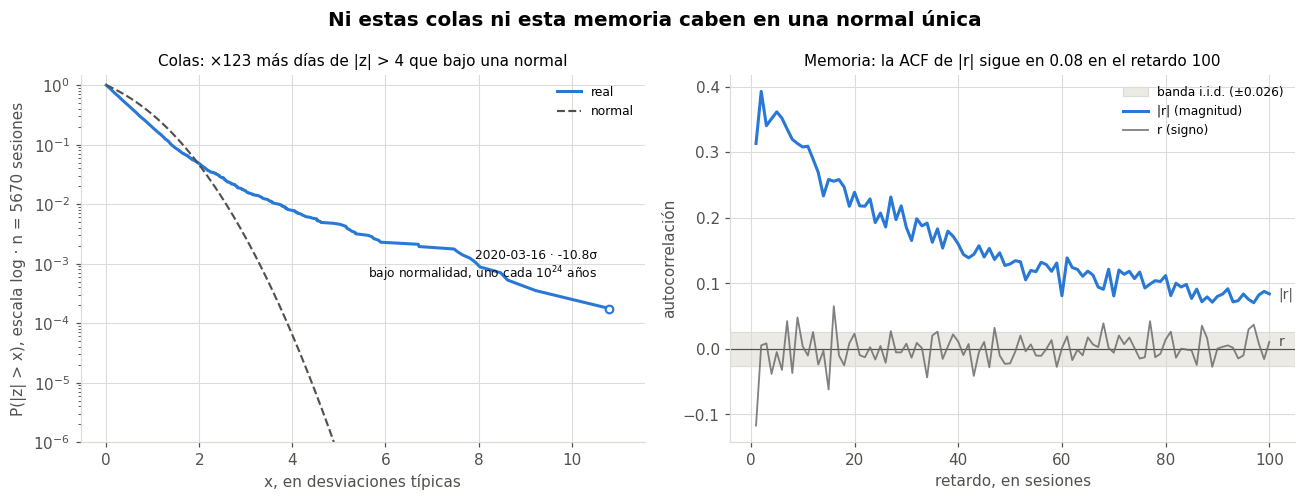

In [20]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.6))
viz.supervivencia_colas(r, eje=ejes[0])
# Sin bajar el suelo del eje la normal se sale por abajo antes de x = 4, y ahí es
# donde el subtítulo del panel afirma su factor: sin verla no se puede comprobar.
ejes[0].set_ylim(1e-6, 1.5)
viz.autocorrelacion_absolutos(r, eje=ejes[1])
fig.suptitle("Ni estas colas ni esta memoria caben en una normal única",
             fontsize=13, fontweight="bold")
viz.guardar(fig, "colas_y_agrupamiento")

### Los diez hechos a la vez, en semianchos de banda

Cada fila se normaliza restando el centro de su banda y dividiendo por su semiancho,
de modo que **la franja sombreada [-1, +1] es la banda** y las diez filas se pueden
leer sobre el mismo eje.

- Hay **más de una fila** donde caen fuera los cuatro procesos —el título dice
  cuántas y van en negrita—, pero tres de ellas son una **identidad, no un
  hallazgo**: la asimetría, la autocorrelación del retorno y el apalancamiento son
  cero por construcción en cuatro procesos i.i.d. y simétricos. Era imposible que
  las reprodujeran.
- La única fila donde los cuatro fallan y el fallo **significa** algo es
  `curtosis_residuos`. Por eso H1 se enuncia sobre ella y no sobre las otras tres.
- `mezcla` cae **dentro** de banda en la curtosis y en la memoria de la magnitud
  —se ve en la figura—, así que apostar por su fracaso en esas dos filas habría
  sido un error. El único sitio donde falla y el fallo cuenta es la cola
  condicional.
- `curtosis_h21` es la gaussianidad agregacional de Cont —bajo agregación las colas
  se adelgazan hacia la normal— y es la fila donde el propio mercado queda más lejos
  del centro de su banda, aunque sin salirse. No aparecía en ninguna otra parte del
  repositorio.

In [21]:
PROCESOS = {"gaussiano": viz.PALETA[4], "t4": viz.PALETA[5],
            "garch11": viz.PALETA[6], "mezcla": viz.PALETA[7]}
_centro = (tabla["banda_inf"] + tabla["banda_sup"]) / 2
_semi = (tabla["banda_sup"] - tabla["banda_inf"]) / 2
assert (_semi > 0).all(), "una banda de semiancho cero haría dividir por cero"
norma = tabla[["sp500", *PROCESOS]].sub(_centro, axis=0).div(_semi, axis=0)
_fuera = ~norma[list(PROCESOS)].abs().le(1)
solos = list(_fuera.index[_fuera.all(axis=1)])

print("Filas donde caen fuera los cuatro procesos:", ", ".join(solos))
print(f"El mercado nunca pasa de {norma['sp500'].abs().max():.2f} semianchos, "
      f"y su extremo está en {norma['sp500'].abs().idxmax()}.")

Filas donde caen fuera los cuatro procesos: curtosis_residuos, asimetria, ac1_retorno, apalancamiento
El mercado nunca pasa de 0.72 semianchos, y su extremo está en curtosis_h21.


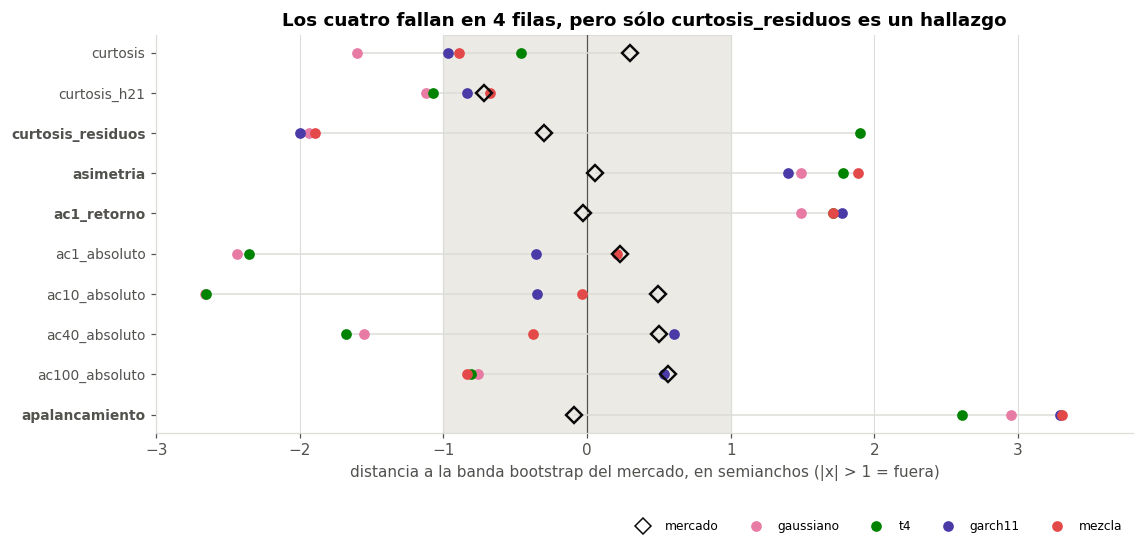

In [22]:
fig, eje = plt.subplots(figsize=(10.5, 5.2))
eje.axvspan(-1, 1, facecolor="#eceae4", edgecolor=viz.REJILLA, lw=0.8, zorder=0)
eje.axvline(0, color=viz.TINTA_SECUNDARIA, lw=0.8, zorder=1)
_y = np.arange(len(norma))[::-1]
for _pos, _fila in zip(_y, norma.index):
    eje.hlines(_pos, norma.loc[_fila].min(), norma.loc[_fila].max(), color=viz.REJILLA, lw=1.0)
    for _p, _t in PROCESOS.items():
        eje.plot(norma.loc[_fila, _p], _pos, marker="o", markersize=6, color=_t, zorder=3)
    # Rombo hueco: relleno en blanco tapaba entero el punto del proceso cuando los
    # dos caían a menos de un tercio de semiancho, y uno de esos puntos es la
    # prueba de que `mezcla` entra en banda en la memoria de la magnitud.
    eje.plot(norma.loc[_fila, "sp500"], _pos, marker="D", markersize=7, zorder=4,
             color=viz.TINTA_PRIMARIA, markerfacecolor="none", markeredgewidth=1.6)
eje.set_yticks(_y, list(norma.index), fontsize=9)
# En negrita las filas donde caen fuera los cuatro: el título dice cuántas son.
for _rot, _fila in zip(eje.get_yticklabels(), norma.index):
    _rot.set_fontweight("bold" if _fila in solos else "normal")
eje.set_xlim(-3.0, 3.8)
eje.grid(False, axis="y")
eje.set_xlabel("distancia a la banda bootstrap del mercado, en semianchos (|x| > 1 = fuera)")
eje.set_title(f"Los cuatro fallan en {len(solos)} filas, pero sólo {solos[0]} "
              f"es un hallazgo", fontsize=12)
eje.legend(handles=[Line2D([], [], marker="D", linestyle="none", markersize=7,
                           markeredgecolor=viz.TINTA_PRIMARIA, markerfacecolor="none",
                           label="mercado")]
                   + [Line2D([], [], marker="o", linestyle="none", markersize=6, color=t,
                             label=p) for p, t in PROCESOS.items()],
           loc="lower right", fontsize=8, ncols=5, bbox_to_anchor=(1.0, -0.28))
viz.guardar(fig, "00_hechos_vs_procesos")

### H1, en unidades nativas

> **H1** · la `curtosis_residuos` del mercado cae **dentro** de su banda bootstrap y
> los cuatro procesos de referencia caen **fuera**. Las cifras exactas las interpola
> el título de la figura siguiente, desde las variables vivas.
> **H1 se refuta si un generador gaussiano entra en la banda.**

Al dividir cada retorno por la volatilidad de las 21 sesiones anteriores, al mercado
le siguen quedando colas y a los cuatro procesos no. `t4` se sale por arriba y los
otros tres por abajo: los cuatro fallan, pero no por el mismo lado, y eso importa
para leer la figura.

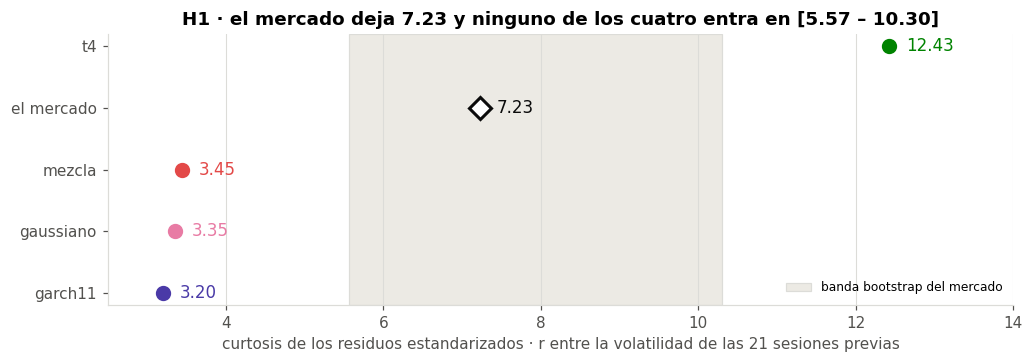

In [23]:
h1 = tabla.loc["curtosis_residuos"]
_inf, _sup = float(h1["banda_inf"]), float(h1["banda_sup"])
_puntos = h1[["sp500", *PROCESOS]].astype(float).sort_values(ascending=False)

fig, eje = plt.subplots(figsize=(9.5, 3.4))
eje.axvspan(_inf, _sup, facecolor="#eceae4", edgecolor=viz.REJILLA, lw=0.8, zorder=0,
            label="banda bootstrap del mercado")
_y = np.arange(len(_puntos))[::-1]
for _pos, (_nombre, _valor) in zip(_y, _puntos.items()):
    _es_mercado = _nombre == "sp500"
    _tono = viz.TINTA_PRIMARIA if _es_mercado else PROCESOS[_nombre]
    eje.plot(_valor, _pos, marker="D" if _es_mercado else "o", markeredgewidth=2.0,
             markersize=10 if _es_mercado else 8, color=_tono,
             markerfacecolor="white" if _es_mercado else _tono, zorder=3)
    eje.annotate(f"{_valor:.2f}", xy=(_valor, _pos), xytext=(11, 0), va="center",
                 textcoords="offset points", fontsize=11, color=_tono)
eje.set_yticks(_y, ["el mercado" if n == "sp500" else n for n in _puntos.index], fontsize=10)
eje.set_xlim(2.5, 14.0)
eje.grid(False, axis="y")
eje.set_xlabel("curtosis de los residuos estandarizados · r entre la volatilidad "
               "de las 21 sesiones previas")
eje.set_title(f"H1 · el mercado deja {h1['sp500']:.2f} y ninguno de los cuatro "
              f"entra en [{_inf:.2f} – {_sup:.2f}]", fontsize=12)
eje.legend(loc="lower right", fontsize=8)
viz.guardar(fig, "00_h1_una_fila")

### La cola condicional, dibujada

La tabla dice que el residuo del mercado conserva cola y el de `garch11` no; esta
figura lo enseña. Sin la tercera curva la figura ilustraría lo que no decide: que el
retorno crudo tiene colas ya lo sabíamos por la figura de arriba.

- La recursión de `garch11` se reproduce **inline**, con los mismos parámetros y la
  misma semilla que `features.calibracion_hechos`, y la celda lleva el `assert` que
  reconcilia su curtosis con la de la tabla antes de pintar nada.
- Las tres curvas se tipifican **globalmente**, cada una con su media y su
  desviación, para que el eje horizontal signifique lo mismo en las tres.

In [24]:
# GARCH(1,1) reproducido con los parámetros y la semilla de `calibracion_hechos`:
# allí `ruido` es el PRIMER sorteo del generador, así que la serie sale idéntica.
_rng = np.random.default_rng(42)
_n, _om, _al, _be = 20_000, 1e-6, 0.09, 0.90
_ruido = _rng.standard_normal(_n)
_var, _serie = np.empty(_n), np.empty(_n)
_var[0] = _om / (1 - _al - _be)
for _i in range(_n):
    if _i:
        _var[_i] = _om + _al * _serie[_i - 1] ** 2 + _be * _var[_i - 1]
    _serie[_i] = np.sqrt(_var[_i]) * _ruido[_i]

def residuos(s, h=config.ventanas().horizonte):
    """r dividido por la volatilidad de las h sesiones anteriores."""
    return (s / s.rolling(h).std().shift(1)).replace([np.inf, -np.inf], np.nan).dropna()

res_mercado, res_garch = residuos(r), residuos(pd.Series(_serie))
assert abs(float(res_garch.kurt() + 3) - float(tabla.loc["curtosis_residuos", "garch11"])) < 1e-9
assert abs(float(res_mercado.kurt() + 3) - float(tabla.loc["curtosis_residuos", "sp500"])) < 1e-9
print(f"Reconciliado con la tabla: garch11 {res_garch.kurt() + 3:.2f}, "
      f"mercado {res_mercado.kurt() + 3:.2f}")

Reconciliado con la tabla: garch11 3.20, mercado 7.23


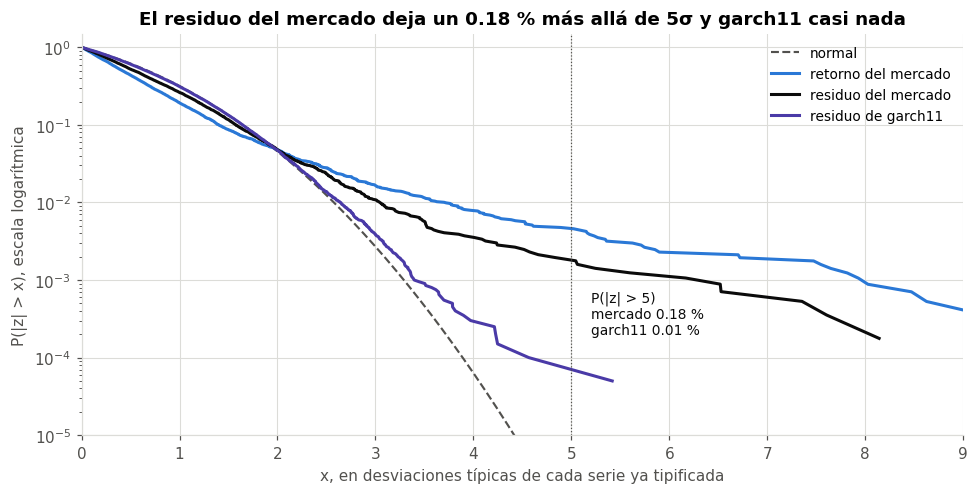

In [25]:
# Las tres curvas se tipifican GLOBALMENTE, cada una con su media y su desviación,
# y las anotaciones se toman ya de las series tipificadas, no de las crudas.
_series = {"retorno del mercado": (r, viz.PALETA[0]),
           "residuo del mercado": (res_mercado, viz.TINTA_PRIMARIA),
           "residuo de garch11": (res_garch, viz.PALETA[6])}
_z = {k: ((s - s.mean()) / s.std()).dropna() for k, (s, _) in _series.items()}

fig, eje = plt.subplots(figsize=(9, 4.6))
_rejilla = np.linspace(0, 9, 400)
eje.semilogy(_rejilla, 2 * norm.sf(_rejilla), color=viz.TINTA_SECUNDARIA,
             linestyle="--", lw=1.4, label="normal")
for _k, (_, _tono) in _series.items():
    _m = np.sort(np.abs(_z[_k].to_numpy()))
    eje.semilogy(_m, 1.0 - np.arange(len(_m)) / len(_m), color=_tono, lw=2.0, label=_k)
eje.axvline(5, color=viz.TINTA_SECUNDARIA, lw=0.8, linestyle=":")
_cola5 = {k: float((np.abs(v) > 5).mean()) * 100 for k, v in _z.items()}
eje.annotate("P(|z| > 5)\n"
             + "\n".join(f"{k.split()[-1]} {v:.2f} %"
                         for k, v in list(_cola5.items())[1:]),
             xy=(5.2, 2e-4), fontsize=9, color=viz.TINTA_PRIMARIA)
eje.set_ylim(1e-5, 1.5)
eje.set_xlim(0, 9)
eje.set_xlabel("x, en desviaciones típicas de cada serie ya tipificada")
eje.set_ylabel("P(|z| > x), escala logarítmica")
eje.set_title(f"El residuo del mercado deja un {_cola5['residuo del mercado']:.2f} % "
              f"más allá de 5σ y garch11 casi nada", fontsize=12)
eje.legend(loc="upper right", fontsize=9)
viz.guardar(fig, "00_colas_condicionales")

### Tres cautelas, dichas antes de que las pregunten

- **La curtosis cruda es frágil.** Cae al eliminar una sola observación, la del 16
  de marzo de 2020, y la celda que construye `tabla` imprime las dos cifras una al
  lado de la otra. Por eso se reporta pero **no se usa como criterio de
  aceptación**.
- **`beta_acf_abs` se retira de la tabla.** El ajuste log-log degenera cuando la ACF
  cruza cero y su banda sale tan ancha que no decide nada; la celda que construye
  `tabla` la guarda e imprime su banda **antes** de descartar la fila, para que el
  descarte se pueda comprobar.
- **El valor de `garch11` en `curtosis_residuos` no es una medición: es una
  identidad algebraica.** `features.calibracion_hechos` simula el GARCH con
  innovación gaussiana (`rng.standard_normal`), de modo que sus residuos
  estandarizados son gaussianos **por construcción**. Esa fila confirma que la
  recursión está bien escrita, no que un GARCH no pueda tener colas condicionales:
  un GARCH con innovación t las tendría. H1 se enuncia igual —lo que se pone a
  prueba es si *nuestros* generadores las reproducen—, pero ésta es la primera
  pregunta que hará el tribunal sobre H1 y conviene tenerla escrita.

### Cómo se mide la memoria de un banco de ventanas

La ACF de |r| de una muestra sintética se mide **agrupando todos los pares de todas
las ventanas**, nunca ventana a ventana promediando después. No es un detalle de
implementación: sobre estos mismos datos las dos formas se separan un orden de
magnitud, y la celda imprime las dos con el factor que las separa.

Una ventana de 60 días es demasiado corta para estimar una autocorrelación cuya
memoria dura cientos de sesiones, y promediar muchas estimaciones malas no produce
una buena. Con el protocolo equivocado, un generador **sin ninguna memoria** pasaría
por bueno.

In [26]:
_pasado = config.ventanas().pasado
_marco = np.abs(r.iloc[:len(r) // _pasado * _pasado].to_numpy()).reshape(-1, _pasado)
_centrado = _marco - _marco.mean(axis=1, keepdims=True)
_num = (_centrado[:, 1:] * _centrado[:, :-1]).sum(axis=1)
_den = (_centrado ** 2).sum(axis=1)
por_ventana = _num[_den > 0] / _den[_den > 0]
agrupado = float(tabla.loc["ac1_absoluto", "sp500"])

print(f"ACF de |r| en el retardo 1, agrupando todos los pares: {agrupado:.4f}")
print(f"Ventana a ventana ({len(por_ventana)} ventanas de {_pasado} días): "
      f"media {por_ventana.mean():.4f}, mediana {np.median(por_ventana):.4f}")
print(f"Factor entre las dos formas de medir: ×{agrupado / por_ventana.mean():.0f}")

ACF de |r| en el retardo 1, agrupando todos los pares: 0.3131
Ventana a ventana (94 ventanas de 60 días): media 0.0264, mediana 0.0123
Factor entre las dos formas de medir: ×12


## 4.3 · ¿Qué aporta cada canal?

Dos preguntas sobre las mismas veinte filas, ordenadas igual para poder leerlas a la
vez.

**Escala** (izquierda): las dispersiones de los canales difieren en órdenes de
magnitud, y el factor exacto lo interpola el subtítulo del panel. Sin escalar por
canal, un modelo optimizaría uno solo e ignoraría el resto. Es la justificación del
escalado del cuaderno 02.

**Señal** (derecha): AUC de cada canal usado como único predictor de "el próximo mes
estará en el decil superior de volatilidad", medido **sólo sobre train**. Cuántos
canales superan el umbral y dónde se queda el mejor retorno lo interpola el
subtítulo; lo que hay que leer es que los que puntúan alto son **todos derivados**.
Sin las derivadas, la tarea de régimen no tendría de dónde agarrarse.

- **La vertical discontinua es el suelo de ruido empírico.** `auc_univariante`
  devuelve `max(AUC, 1-AUC)`, y su propio docstring avisa de que un canal de puro
  ruido no da 0,50 exacto sino algo por encima. La celda anterior lo mide permutando el objetivo
  una vez con la semilla del proyecto. Los retornos diarios caen prácticamente sobre
  esa línea.
- El AUC va sin banda y conviene decirlo: D3 (panel híbrido de 20 canales en vez de
  23 tickers en crudo, `docs/DECISIONES.md`) la sitúa en torno a ±0,15 con el mismo
  bootstrap —**medición externa que este cuaderno no recalcula**—, así que lo
  defendible es la separación entre los dos bloques, no el orden entre canales
  vecinos.

In [27]:
familias = config.familias_canales()
hasta = config.particiones().train_hasta
auc = features.auc_univariante(canales, objetivos["vol_futura"], hasta=hasta)
correlacion = features.correlacion_media(canales, objetivos["vol_futura"], hasta=hasta)

print("AUC sobre train ·", int(auc["n"].iloc[0]), "ventanas,", int(auc["positivos"].iloc[0]), "positivas")
print(f"Correlación media entre sectores · calma {correlacion['calma']:.3f} "
      f"({int(correlacion['n_calma'])} sesiones) · estrés {correlacion['estres']:.3f} "
      f"({int(correlacion['n_estres'])} sesiones)")

AUC sobre train · 3755 ventanas, 376 positivas
Correlación media entre sectores · calma 0.615 (3379 sesiones) · estrés 0.786 (376 sesiones)


In [28]:
# `auc_univariante` devuelve max(AUC, 1-AUC), así que un canal de puro ruido no da
# 0,50 exacto. El suelo se mide permutando el objetivo con la semilla del proyecto.
_rng = np.random.default_rng(config.cargar_catalogo()["semilla_global"])
_permutado = pd.Series(
    _rng.permutation(objetivos["vol_futura"].reindex(canales.index).to_numpy()),
    index=canales.index)
suelo_auc = float(features.auc_univariante(canales, _permutado, hasta=hasta)["auc"].max())

print(f"Suelo de ruido con el objetivo permutado: {suelo_auc:.3f} · canales por "
      f"encima de 0,70: {int((auc['auc'] > 0.70).sum())}")

Suelo de ruido con el objetivo permutado: 0.524 · canales por encima de 0,70: 6


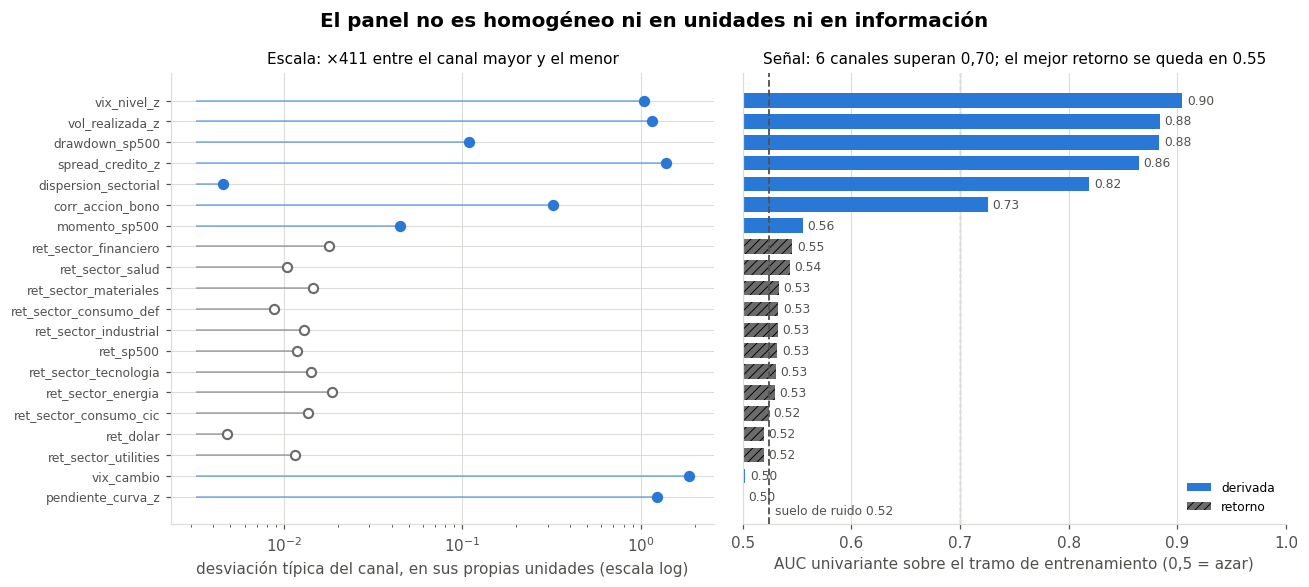

In [29]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 5.4), sharey=True)
viz.puntos_escala(canales.std().reindex(auc.index), familias, eje=ejes[0])
viz.barras_auc(auc["auc"], familias, eje=ejes[1]); ejes[1].tick_params(axis="y", length=0)
# Tinta secundaria y discontinua, no el rojo de la paleta: en este cuaderno ese
# rojo es el proceso `mezcla`, y una referencia no puede llevar color de serie.
ejes[1].axvline(suelo_auc, color=viz.TINTA_SECUNDARIA, lw=1.2, linestyle="--", zorder=3)
ejes[1].annotate(f"suelo de ruido {suelo_auc:.2f}", xy=(suelo_auc, 0.015),
                 xycoords=ejes[1].get_xaxis_transform(), xytext=(4, 0), va="bottom",
                 textcoords="offset points", fontsize=8, color=viz.TINTA_SECUNDARIA)
fig.suptitle("El panel no es homogéneo ni en unidades ni en información",
             fontsize=13, fontweight="bold")
viz.guardar(fig, "perfil_de_canales")

### 4.3.1 · La correlación no es estable

Si la correlación transversal fuese estable, un generador incondicional bastaría. No
lo es: al pasar a estrés **sube en todos los pares sectoriales**, y el título dice en
cuántos de cuántos. Es lo que justifica condicionar los generadores por régimen.

- El estrés se define **igual que el proxy del AUC** —decil superior de `vol_futura`
  dentro de train— y no de otra forma, para que los dos números sean comparables. La
  celda lleva el `assert` que reconcilia las dos medias con
  `features.correlacion_media` antes de pintar.
- Es un *dumbbell* y no dos histogramas porque lo que importa es el **emparejado**:
  cada segmento es el mismo par de sectores medido dos veces.
- La estimación de estrés se apoya en muchas menos sesiones que la de calma —la
  leyenda dice cuántas de cada—, así que la **dirección** del movimiento es mucho más
  firme que su nivel exacto. Por eso el titular es "suben todos" y no una comparación
  entre los extremos de las dos nubes, que se cae con cualquier reestimación.

In [30]:
# Misma máscara de estrés que `features.correlacion_media` —decil superior de
# vol_futura dentro del tramo de entrenamiento— y su assert de reconciliación.
_sectores = [c for c in canales.columns if c.startswith("ret_sector_")]
_y_vol = objetivos["vol_futura"].reindex(canales.index)[canales.index <= pd.Timestamp(hasta)]
_ret = canales.loc[_y_vol.index, _sectores]
_val = _y_vol.notna()
_es_estres = _val & (_y_vol >= _y_vol[_val].quantile(0.9))
_iu = np.triu_indices(len(_sectores), 1)
calma = _ret[_val & ~_es_estres].corr().to_numpy()[_iu]
estres = _ret[_es_estres].corr().to_numpy()[_iu]

assert abs(calma.mean() - correlacion["calma"]) < 1e-12
assert abs(estres.mean() - correlacion["estres"]) < 1e-12
print(f"{len(calma)} pares · suben {int((estres > calma).sum())} · "
      f"el mínimo en estrés ({estres.min():.4f}) y la mediana en calma "
      f"({np.median(calma):.4f}) distan {estres.min() - np.median(calma):.4f}")

36 pares · suben 36 · el mínimo en estrés (0.6315) y la mediana en calma (0.6302) distan 0.0013


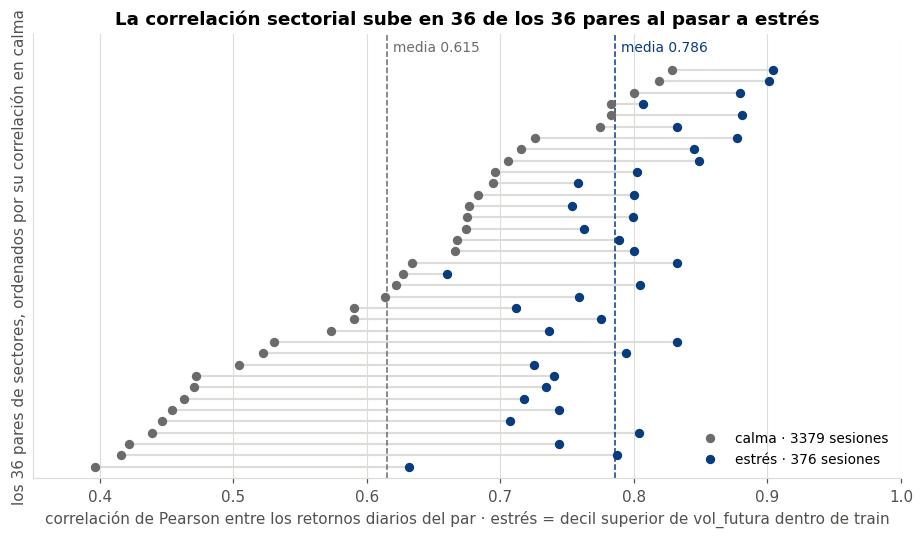

In [31]:
# El estrés va con el tono oscuro de la rampa de regímenes, el mismo que tiñe los
# bloques del carril: dentro de un cuaderno un color no puede significar dos cosas.
_tono_estres = viz.rampa_secuencial(3)[2]
_orden = np.argsort(calma)
_pos = np.arange(len(_orden))

fig, eje = plt.subplots(figsize=(8.5, 5.0))
for _k, _i in enumerate(_orden):
    eje.plot([calma[_i], estres[_i]], [_k, _k], color=viz.REJILLA, lw=1.4, zorder=1)
eje.scatter(calma[_orden], _pos, s=26, color=viz.GRIS_CONTEXTO, zorder=3,
            label=f"calma · {int(correlacion['n_calma'])} sesiones")
eje.scatter(estres[_orden], _pos, s=26, color=_tono_estres, zorder=3,
            label=f"estrés · {int(correlacion['n_estres'])} sesiones")
for _v, _t in ((calma.mean(), viz.GRIS_CONTEXTO), (estres.mean(), _tono_estres)):
    eje.axvline(_v, color=_t, linestyle="--", lw=1.0, zorder=2)
    eje.annotate(f"media {_v:.3f}", xy=(_v, len(_orden) + 1.9), xytext=(4, -2), va="top",
                 textcoords="offset points", fontsize=9, color=_t)
eje.set_yticks([])
eje.set_ylim(-1.0, len(_orden) + 2.2)
eje.set_xlim(0.35, 1.0)
eje.grid(False, axis="y")
eje.set_ylabel(f"los {len(_orden)} pares de sectores, ordenados por su correlación en calma")
eje.set_xlabel("correlación de Pearson entre los retornos diarios del par · "
               "estrés = decil superior de vol_futura dentro de train")
eje.set_title(f"La correlación sectorial sube en {int((estres > calma).sum())} de los "
              f"{len(_orden)} pares al pasar a estrés", fontsize=12)
eje.legend(loc="lower right", fontsize=9)
viz.guardar(fig, "00_correlacion_regimen")

La última medición de la sección mira lo mismo desde el otro lado: en los peores
días del índice, cuántas veces caen a la vez todos los sectores y quién sube. Esa
comparación **no lleva figura** —sería una nube de decenas de miles de puntos, y una
nube así no se lee—, así que su argumento va entero en un `print`.

In [32]:
# El argumento de la figura que NO se hace: una nube de decenas de miles de puntos
# no se lee, pero su cifra sí se mide. "Peor sesión" = 5 % inferior de `ret_sp500`.
_peores = canales["ret_sp500"] <= canales["ret_sp500"].quantile(0.05)
_refugios = {a: precios[a].pct_change().reindex(canales.index)[_peores]
             for a in ("vix", "tesoro_20y", "tesoro_10y")}

print(f"En las {int(_peores.sum())} peores sesiones del índice (el 5 % inferior):")
print(f"  los {len(_sectores)} sectores caen a la vez en el "
      f"{(canales.loc[_peores, _sectores] < 0).all(axis=1).mean() * 100:.0f} % de ellas")
for _a, _s in _refugios.items():
    print(f"  {_a} sube en el {(_s > 0).mean() * 100:.0f} % de ellas, "
          f"un {_s.mean() * 100:+.2f} % de media")
print("  la cobertura del panel está en el VIX y en la duración, no en los sectores")

En las 284 peores sesiones del índice (el 5 % inferior):
  los 9 sectores caen a la vez en el 79 % de ellas
  vix sube en el 97 % de ellas, un +16.92 % de media
  tesoro_20y sube en el 79 % de ellas, un +0.83 % de media
  tesoro_10y sube en el 79 % de ellas, un +0.40 % de media
  la cobertura del panel está en el VIX y en la duración, no en los sectores


## Qué se lleva el resto del proyecto

- **El dataset.** `canales.parquet` y `objetivos.parquet`, con las dimensiones y las
  huellas que imprimieron sus celdas. El cuaderno 01 usa cinco canales para el HMM;
  el 02 los apila en ventanas.
- **La hipótesis H1**, que los cuadernos 05 a 10 tienen que intentar refutar, con la
  cautela de que el valor de `garch11` en esa fila es una identidad algebraica y no
  una medición.
- **El tamaño muestral efectivo**, que es lo que hay que citar en cualquier intervalo
  de confianza: bloques disjuntos y episodios de estrés, no ventanas nominales. Los
  recuentos del panel y los de train los imprime la celda 4.1, y el 45 del README es
  **otra convención**, la del cuaderno 02: no se reconcilian y no hace falta que lo
  hagan.
- **Un protocolo.** La ACF de |r| de las muestras sintéticas se mide agrupando todos
  los pares de todas las ventanas, nunca ventana a ventana promediando después. La
  celda de «Cómo se mide la memoria de un banco de ventanas» imprime las dos cifras
  y el factor que las separa, y con la segunda un generador sin ninguna memoria
  pasaría por bueno.

### El hilo hacia el cuaderno 03

La cadena que sostiene la presentación empieza aquí, y este cuaderno es el dueño de
su primer eslabón: **un puñado de episodios de crisis independientes en train → unas
decenas de bloques disjuntos → un downstream famélico**. Cuando el cuaderno 03
publique una banda de confianza ancha para el recall de crisis, eso no será un
defecto del modelo: será esta escasez, medida aquí, propagándose hasta el final. D21
(`docs/DECISIONES.md`) lo dice en su forma operativa: con este tamaño muestral,
ninguna diferencia de recall de crisis menor de unos veinte puntos es distinguible
del ruido.

In [33]:
_h1 = tabla.loc["curtosis_residuos"]
_mejor_retorno = auc["auc"][(familias.reindex(auc.index) == "retorno").to_numpy()].max()
_nominales = f"{int(efectivo['ventanas_nominales']):,}".replace(",", ".")

print("Lo que este cuaderno entrega")
print(f"  H1 · curtosis_residuos del mercado {_h1['sp500']:.2f}, banda "
      f"[{_h1['banda_inf']:.2f} – {_h1['banda_sup']:.2f}], y los cuatro procesos fuera")
print(f"  Señal · {int((auc['auc'] > 0.70).sum())} canales pasan de 0,70 de AUC sobre "
      f"train con suelo de ruido {suelo_auc:.2f}; el mejor retorno diario deja "
      f"{_mejor_retorno:.2f}")
print(f"  Escasez · {_nominales} ventanas son {int(efectivo['bloques_disjuntos'])} bloques "
      f"disjuntos, {len(episodios)} episodios de estrés y {crisis_entrenables} crisis "
      f"entrenables en train")

Lo que este cuaderno entrega
  H1 · curtosis_residuos del mercado 7.23, banda [5.57 – 10.30], y los cuatro procesos fuera
  Señal · 6 canales pasan de 0,70 de AUC sobre train con suelo de ruido 0.52; el mejor retorno diario deja 0.55
  Escasez · 5.590 ventanas son 70 bloques disjuntos, 11 episodios de estrés y 2 crisis entrenables en train


### Salidas generadas

La celda anterior imprime las tres cifras que este cuaderno entrega; ésta comprueba
que todos los ficheros que promete existen de verdad en el disco.

In [34]:
from pathlib import Path

salidas = [
    src.DIR_CRUDO / "precios.parquet",
    src.DIR_PROCESADO / "canales.parquet",
    src.DIR_PROCESADO / "objetivos.parquet",
    src.DIR_FIGURAS / "panel_mercado.png",
    src.DIR_FIGURAS / "00_activacion_canales.png",
    src.DIR_FIGURAS / "mapa_canales.png",
    src.DIR_FIGURAS / "muestra_efectiva.png",
    src.DIR_FIGURAS / "00_episodios_de_estres.png",
    src.DIR_FIGURAS / "00_escasez_estructural.png",
    src.DIR_FIGURAS / "colas_y_agrupamiento.png",
    src.DIR_FIGURAS / "00_hechos_vs_procesos.png",
    src.DIR_FIGURAS / "00_h1_una_fila.png",
    src.DIR_FIGURAS / "00_colas_condicionales.png",
    src.DIR_FIGURAS / "perfil_de_canales.png",
    src.DIR_FIGURAS / "00_correlacion_regimen.png",
]

for ruta in salidas:
    ruta = Path(ruta)
    print("[{}] {}".format("ok" if ruta.exists() else "--", ruta.relative_to(src.RAIZ)))

[ok] data\raw\precios.parquet
[ok] data\processed\canales.parquet
[ok] data\processed\objetivos.parquet
[ok] results\figures\panel_mercado.png
[ok] results\figures\00_activacion_canales.png
[ok] results\figures\mapa_canales.png
[ok] results\figures\muestra_efectiva.png
[ok] results\figures\00_episodios_de_estres.png
[ok] results\figures\00_escasez_estructural.png
[ok] results\figures\colas_y_agrupamiento.png
[ok] results\figures\00_hechos_vs_procesos.png
[ok] results\figures\00_h1_una_fila.png
[ok] results\figures\00_colas_condicionales.png
[ok] results\figures\perfil_de_canales.png
[ok] results\figures\00_correlacion_regimen.png
